# **Tutorial 1** $\cdot$ Feature Attribution Methods

> **Abstract.** To be written at the end.


**💾 Dataset.** This notebook will make use of the [AqSolDB](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) 
dataset introduced by [Sorkun et al.](https://www.nature.com/articles/s41597-019-0151-1). Its a curated dataset consisting of roughly ten thousand 
small molecules annotated with experimentally determined [water solubility](https://en.wikipedia.org/wiki/Solubility) values. These target annotations were curated and consolidated from 
various sources throughout the literature. Due to it's experimental nature and the presence of measurement noise, it is important to note that 
it is impossible to achieve perfect prediction accuracy for this dataset. Based on results from the literature, the practical limit to the 
performance likely is a predictivity (R² score) in the range between 0.86 and 0.89.

**📦 Packages.** Packages used in this notebook inlcude:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and the calculation of molecular descriptors and fingerprints.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of simple neural network models based on the molecular representations.
- [shap](https://github.com/shap/shap) for the calculation and the plotting of the attributional explanations.

In [3]:
import os
import random

import torch
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rdkit.Chem as Chem
import rdkit.Chem.Crippen
import rdkit.Chem.Descriptors
import lightning.pytorch as pl
import torch.nn as nn
import torch.nn.functional as F
from rich.pretty import pprint
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import Subset

from xai_chem_review import load_dataset_aqsoldb

The `load_dataset_aqsoldb` function loads and returns the dataset - currently stored as a CSV file - into a pandas `DataFrame` object. In its base form, the dataset represents each molecule as a [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) string. To calculate the molecular descriptors and fingerprint representations for these compounds, however, we need some kind of molecular graph representation. For this purpose we convert each SMILES string into an RDKit `Mol` object and add these as a separate row to the data frame

In [4]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
data_frame.head()

Loaded dataset with 11024 rows


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


In [5]:
data_frame['mol'] = data_frame['smiles'].apply(Chem.MolFromSmiles)
data_frame = data_frame.dropna(subset=['mol']).reset_index(drop=True)
print(f'After mol conversion {data_frame.shape[0]} rows remaining')

[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not removing hydrogen atom without neighbors
[14:37:53] WARNING: not r

After mol conversion 11022 rows remaining


## **1.1** $\cdot$ 💡 Attributional Explanations

This section will motivate and introduce the concept of attributional explanations in general before jumping into the concrete example explanations.

In explainable AI (xAI), an *explanation* is supposed to add additional, human-interpretable information to the prediction of a complex machine-learning model. In the case of *attributional explanations*, this additional information is presented by revealing how much importance is attributed to different parts of the given input data structure. In other words, these explanations reveal how the models prioritize different aspects of the input data in their decisions. Among all the information that is passed to the model, certain aspects will be more important than others. In the classic example of credit score prediction, a model will likely have learned to base it's prediction on the montly income rather than the eye color of the applicant. The purpose of attributional explanations is exactly to reveal these learned priorities.

In the context of molecular property prediction, one can further differentiate attributional explanations into the two classes of *feature-attribution* methods and *structure-attribution* method. Structure-attribution methods aim to directly find certain substructures or motifs within the molecular graph structure itself, which are particularly important for the prediction. Feature-attribution methods on the other hand operate on the level of abstract features that can be assigned to certain molecules. In the end, both methods my communicate very similar information but primarily differ in how this information is *presented* and in the kinds of explanation methods with which they can be obtained.

[Insert example image]

## **1.2** $\cdot$ 📚 *SHapley Additive ExPlanations* (`SHAP`)

The first example method from the literature was proposed by [Lundberg *et al.*](https://arxiv.org/abs/1705.07874) and has been cited over thirty thousand times. The method of *SHapely Additive exPlanations (SHAP)* leverages the concept of shapely values from cooperative game theory to calculate how much each certain feature contributes towards the final prediction outcome. One particular advantage of SHAP is that it is a model agnostic post-hoc method. This means that it can be applied to (almost) any kind of machine learning model after it has already been trained, without having to modify the model itself.

**Implementation.** From an implementation perspective, there exist a feature-rich and relatively well-maintained python package called `shap`. The package implements the core explanation methods for various different use-cases such as text-based, image-based or tabular data. The package also provides several functions which can be used to plot these explanations to present them in a human-interpretable format.

### Molecular Descriptor Generation

In the very first step, we need to generate the molecular descriptors which will serve as the basis of a machine learning model to predict the water solubility. There already exist pre-defined functions to calculate the full descriptor vectors for a molecule right away in several cheminformatics packages, including RDKit. However, in this instance it makes sense to already think about the explanations that we want to generate later - particularly how these explanations will be visualized. 

In [ ]:
class DescriptorGenerator:
    """
    A class to generate molecular descriptors for a given molecule.
    """
    
    # This dictionary defines which molecular descriptors will be generated and how they are calculated. The 
    # keys of the dictionary are the names of the descriptors and the corresponding values are again dictionaries
    # which supply the necessary information about that descriptor. For each descriptor the following three 
    # keys are required:
    # - `name`: A human-readable name for the descriptor.
    # - `description`: A human-readable description of the descriptor.
    # - `function`: A callable function that accepts an RDKit `Mol` object and returns a list of float values 
    #   representing the corresponding descriptor values.
    DESCRIPTOR_DETAIL_MAP: dict[str, dict] = {
        'clogp': {
            'name': 'Crippen LogP',
            'description': 'Fragment-based Crippen LogP approximation',
            'function': lambda mol: [Chem.Crippen.MolLogP(mol)],
        },
        'cmr': {
            'name': 'Crippen Molecular Refractivity',
            'description': 'Fragment-based Crippen Molecular Refractivity approximation',
            'function': lambda mol: [Chem.Crippen.MolMR(mol)],
        },
        'weight': {
            'name': 'Molecular Weight',
            'description': 'Molecular weight',
            'function': lambda mol: [Chem.Descriptors.MolWt(mol)],
        },
        'num_aromatic_rings': {
            'name': 'Num. Aromatic Rings',
            'description': 'Number of aromatic rings',
            'function': lambda mol: [Chem.Descriptors.NumAromaticRings(mol)],
        },
        'num_h_donors': {
            'name': 'Num. H-bond Donors',
            'description': 'Number of hydrogen bond donors',
            'function': lambda mol: [Chem.Descriptors.NumHDonors(mol)],
        },
        'num_h_acceptors': {
            'name': 'Num. H-bond Acceptors',
            'description': 'Number of hydrogen bond acceptors',
            'function': lambda mol: [Chem.Descriptors.NumHAcceptors(mol)],
        },
        'num_rotatable_bonds': {
            'name': 'Num. Rotatable Bonds',
            'description': 'Number of rotatable bonds',
            'function': lambda mol: [Chem.Descriptors.NumRotatableBonds(mol)],
        },
        'num_valence_electrons': {
            'name': 'Valence Electron Count',
            'description': 'Number of valence electrons',
            'function': lambda mol: [Chem.Descriptors.NumValenceElectrons(mol)],
        },
        'num_halogen_frags': {
            'name': 'Num. Halogen Fragments',
            'description': 'Number of halogen fragments',
            'function': lambda mol: [Chem.Descriptors.fr_halogen(mol)],
        }
    }
    
    def get_descriptor_vector(self, value: str | Chem.Mol) -> list[float]:
        """
        Given the RDKit.Mol object `value`, this method returns a list of float values representing 
        the molecular descriptor vector as it is defined by the `self.DESCRIPTOR_DETAIL_MAP` 
        dictionary structure.
        
        :param value: Either a SMILES string or an RDKit.Mol object representing the molecule for which
            for which the descriptor vector should be calculated.
            
        :return: A list of float values representing the molecular descriptor vector.
        """
        
        # We'll accept the input argument as either a SMILES string representation, which we first 
        # need to convert to a mol object, or a mol object directly.
        if isinstance(value, str):
            mol: Chem.Mol = Chem.MolFromSmiles(value)
        else:
            mol: Chem.Mol = value
        
        # This list will contain all of the actually calculated descriptor values and is converted 
        # into a numpy array at the end.
        values: list[float] = []
        # Using the Mol object, we can generate the descriptor vector by iteratively applying all 
        # of the descriptor-producing functions defined in the DESCRIPTOR_DETAIL_MAP
        for descriptor_name, descriptor_info in self.DESCRIPTOR_DETAIL_MAP.items():
            values += descriptor_info['function'](mol)
            
        return values
    
    # --- properties ---
    
    @property
    def descriptor_names(self) -> list[str]:
        """
        A list of all the human-readable descriptor names in the same order as the actual values in the 
        descriptor vectors calculated by this class.
        """
        descriptor_names: list[str] = [
            descriptor_info['name']
            for descriptor_key, descriptor_info in self.DESCRIPTOR_DETAIL_MAP.items()
        ]
        return descriptor_names
    
    def __len__(self) -> int:
        """
        Returns the number of descriptors generated by this generator for each molecule.
        """
        return len(self.DESCRIPTOR_DETAIL_MAP)
        
        
# --- example usage ---

smiles: str = 'Cc1cccc(C=C)c1'
print('Generating example descriptor vector for SMILES: ', smiles)

descriptor_generator = DescriptorGenerator()
descriptors: np.ndarray = descriptor_generator.get_descriptor_vector(smiles)
pprint(descriptors)


Generating example descriptor vector for SMILES:  Cc1cccc(C=C)c1


[2.638020000000001, 41.27000000000002, 118.17899999999999, 1, 0.0, 0, 0, 1, 46, 0]

Using the instance of the `DescriptorGenerator` class we can now convert all the Mol objects of the dataset into their corresponding descriptor vector representations and add them as an additional column of the data frame.

In [39]:
# --- generating descriptors for dataset ---

data_frame['descriptors'] = data_frame['mol'].apply(descriptor_generator.get_descriptor_vector)
data_frame[['smiles', 'descriptors', 'solubility']].head()

,smiles,descriptors,solubility
0,Cc1cccc(C=C)c1,"[2.638020000000001, 41.27000000000002, 118.178...",-3.123150
1,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,"[4.657380000000004, 87.28960000000004, 284.399...",-4.952869
2,O=C1CCCCCCCCCOCCCCCO1,"[3.850900000000003, 72.56500000000005, 256.385...",-3.883849
3,CCCCCCCCCCC(C)CCCCCCCC,"[7.903900000000008, 94.38400000000009, 282.556...",-6.451105
4,NC(=O)N=NC(N)=O,"[-0.40399999999999986, 24.022800000000007, 116...",-3.546243


<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.1** $\cdot$ Add the [Topological Polar Surface Area (TPSA)](https://en.wikipedia.org/wiki/Polar_surface_area) as an additional value in the vector of descriptors.

</div>

### Model Training

As a next step we want to train a simple neural network model to predict the water solubility based on the descriptor vector that we've just defined. To train the network, we'll be using the [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) library. In order to do so, however, the dataset needs to be processed into a pytorch-compatible format. More specifically, pytorch lightning expects the data to be packaged into `DataLoader` instances. These data loader objects automatically handle the shuffling and batching of the data during training. One such data loader itself can be created from a pytorch `TensorDataset`.

In addition to this conversion, it also makes sense to split the available data into a disjunct *train* and a *test* set to evaluate the model performance later on.

In [ ]:
# --- train-test split ---
indices = range(len(data_frame))
test_indices = random.sample(indices, k=int(len(data_frame) * 0.2))
train_indices = list(set(indices) - set(test_indices))

# --- creating tensor dataset ---
# We first need to convert the dataset into `torch.Tensor` objects for the input descriptor vectors and the target values separately.
# We can then use both of the resulting vectors to create a `TensorDataset` object for the entire dataset as a whole.

xs: torch.Tensor = torch.tensor(data_frame['descriptors'].to_list(), dtype=torch.float32)
ys: torch.Tensor = torch.tensor(data_frame['solubility'].to_list(), dtype=torch.float32)

dataset = TensorDataset(xs, ys)

# --- creating dataloaders ---

# Using the whole dataset and the previously split train and test indices, the Subset class can be used to select only a subset of 
# the dataset for further processing.
dataset_train = Subset(dataset, train_indices)
dataset_test = Subset(dataset, test_indices)

# Finally, we can create the `DataLoader` objects from both of these subset instances. Since these data loaders automatically handle the 
# shuffling and batching of the data during training, they need to receive the batch size as a constructor argument.
# The `num_workers` argument specifies how many subprocesses to use for data loading. Together with a reasonable `prefetch_factor`, this 
# ensures that the data is loaded efficiently during training - preventing performance bottlenecks.
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=4, prefetch_factor=2)
loader_test = DataLoader(dataset_test, batch_size=32, shuffle=False)

In [ ]:
from torchmetrics.functional import r2_score

# --- densely connected neural network model ---

class SimpleModel(pl.LightningModule):
    """
    Simple multi-layer densely connected neural network model for the regression of continuous target values 
    based on fixed-length input vector representations.
    
    :param input_dim: The number of input features (length of the descriptor vector).
    :param output_dim: The number of output features (as many as there are target values to predict)
    """
    
    def __init__(self, 
                 input_dim: int, 
                 output_dim: int
                 ) -> None:
        super().__init__()
        self.save_hyperparameters()
        
        # Defining the neural network structure
        self.model = torch.nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Linear(64, output_dim)
        )
        
    def predict_tensor(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            y_hat_tensor = self.model(x)
            return y_hat_tensor.squeeze()
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Model forward pass based on the batched input tensor `x`.
        
        :param x: Input tensor of shape (batch_size, input_dim)
        
        :returns: The model prediction tensor of shape (batch_size, output_dim)
        """
        return self.model(x)
    
    def training_step(self, 
                      batch: tuple[torch.Tensor, torch.Tensor], 
                      batch_idx: int
                      ) -> torch.Tensor:
        """
        Implementation of the training step. Receives each training `batch` as a tuple of the input tensor `x` and 
        the corresponding ground truth traget values `y`.
        Defines the loss function as the mean squared error (MSE) between the true values and the model prediction 
        and returns the resulting loss value.
        """
        
        x, y = batch
        y_hat = self.forward(x)
        loss = F.mse_loss(y_hat.squeeze(), y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        y_hat = self.forward(x)
        loss = F.mse_loss(y_hat.squeeze(), y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)

        # Calculate R^2 score using torchmetrics
        r2 = r2_score(y_hat.squeeze(), y)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True)
        
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)
    

# --- instantiating the model ---
    
model = SimpleModel(
    # We can use the length attribute of the descriptor generator to figure out how many features / descriptors
    # were generated for each molecule.
    input_dim=len(descriptor_generator),
    # We want to predict the single solubility value for each molecule.
    output_dim=1,
)

print('--- Testing the model ---')
x_example = torch.tensor(np.random.rand(10, len(descriptor_generator)), dtype=torch.float32)  # 10 vectors
y_example = model(x_example)
print(f'Example predictions for random input vectors (shape: {y_example.shape}):', y_example)


--- Testing the model ---
Example predictions for random input vectors (shape: torch.Size([10, 1])): tensor([[-0.3341],
        [ 0.0695],
        [ 0.6304],
        [ 0.0693],
        [ 0.1072],
        [ 0.1152],
        [-0.1870],
        [ 0.1032],
        [-0.2377],
        [-0.0670]], grad_fn=<AddmmBackward0>)


In [ ]:
# --- model training ---

trainer = pl.Trainer(
    # number of epochs
    # For simple models and small datasets like this, 25 epochs should be sufficient to converge reasonably well.
    max_epochs=25,
    # If a GPU is available, use it for the training. Otherwise, use the CPU.
    accelerator='auto',
)

trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

# This puts the model into evaluation mode. In this case that primarly means that the 
model.eval()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 20.0 K | train
---------------------------------------------
20.0 K    Trainable params
0         Non-trainable params
20.0 K    Total params
0.080     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


/media/ssd/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


Epoch 4:   1%|          | 2/276 [00:00<02:01,  2.25it/s, v_num=11, train_loss_step=2.030, val_loss=2.450, val_r2=0.532, train_loss_epoch=1.860]  

3755.70s - thread._ident is None in _get_related_thread!


Epoch 9:   0%|          | 0/276 [00:00<?, ?it/s, v_num=11, train_loss_step=1.090, val_loss=2.360, val_r2=0.552, train_loss_epoch=1.680]          

...

3893.76s - thread._ident is None in _get_related_thread!


Epoch 24: 100%|██████████| 276/276 [00:08<00:00, 31.11it/s, v_num=11, train_loss_step=2.770, val_loss=2.160, val_r2=0.577, train_loss_epoch=1.560]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 276/276 [00:08<00:00, 31.06it/s, v_num=11, train_loss_step=2.770, val_loss=2.160, val_r2=0.577, train_loss_epoch=1.560]


SimpleModel(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.2** $\cdot$ Change loss function of the model into a [Huber Loss](https://en.wikipedia.org/wiki/Huber_loss) and re-train the network.

</div>

### Attributional Explanations

In [50]:
# --- setting up the explainer ---

# Selecting 100 samples from the dataset to use as background data for SHAP
background_indices = random.sample(train_indices, k=100)
background_tensor = torch.tensor(xs[background_indices].numpy())

explainer = shap.DeepExplainer(
    model=model,
    data=background_tensor,
)

# --- calculating SHAP values ---
test_tensor = torch.tensor(xs[test_indices].numpy())
shap_values: shap.Explanation = explainer.shap_values(test_tensor)
base_values = np.repeat(np.array(explainer.expected_value), test_tensor.shape[0], axis=0)
shap_exp: shap.Explanation = shap.Explanation(
    values=np.squeeze(shap_values),
    base_values=base_values,
    data=test_tensor.numpy(),
    feature_names=descriptor_generator.descriptor_names,
)
pprint(shap_exp, max_length=10)

.values =
array([[-0.76701057,  0.21241565, -0.83162004, ...,  0.56627607,
│   │    0.09400872,  0.01343022],
│      [-1.27045298,  0.42148578,  0.06995157, ..., -0.09009925,
│   │   -0.04906894, -0.08373243],
│      [-1.44391346, -0.04323326, -0.98698801, ...,  0.04293648,
│   │    0.24106653, -0.01985036],
│      ...,
│      [-2.06616449, -0.84680712, -0.39253342, ...,  0.21397014,
│   │    0.10345502, -0.33393449],
│      [ 1.0120554 , -0.46691567, -0.81248504, ...,  0.05132462,
│   │    0.74668694,  0.04283172],
│      [-0.36401141, -0.1163925 , -0.15061277, ..., -0.19638886,
│   │    0.55824459,  1.01378644]])

.base_values =
array([-2.7317386, -2.7317386, -2.7317386, ..., -2.7317386, -2.7317386,
│      -2.7317386], dtype=float32)

.data =
array([[  3.3652,  62.802 , 290.189 , ...,  10.    , 104.    ,   0.    ],
│      [  3.6271,  55.233 , 160.26  , ...,   1.    ,  64.    ,   0.    ],
│      [  4.1048,  68.7707, 239.746 , ...,   4.    ,  88.    ,   1.    ],
│      ...,
│      [  5.6015,  78.0115, 365.964 , ...,   5.    , 106.    ,   4.    ],
│      [  0.5021,  70.0495, 265.309 , ...,   4.    , 104.    ,   0.    ],
│      [  2.6496,  21.6   , 170.92  , ...,   0.    ,  50.    ,   6.    ]],
│     dtype=float32)

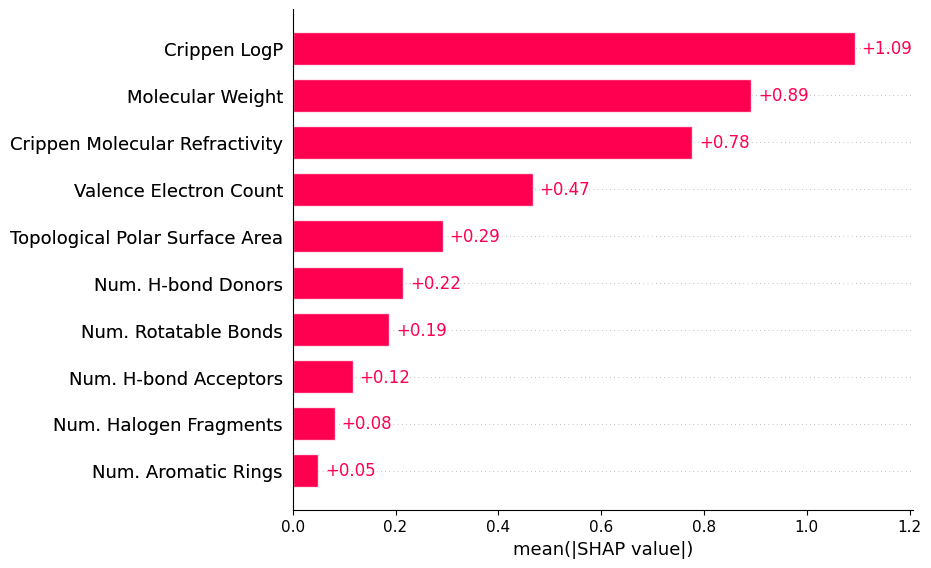

In [51]:
# --- visualizing explanations ---

ax = shap.plots.bar(shap_exp, show=False, max_display=10)

**📊 Feature Importance Plot.** This first plot illustrates the absolute feature importance for the various molecular descriptors. The vertical axis shows the human-readable names of the descriptors that were defined above and the bars along the horizontal axis show the average absolute value of the SHAP values for those features. Generally, a larger bar indicates more important features. An analysis of the absolute importance like this already presents valuable information, but it still misses the information *how* exactly these features are important for the prediction outcome.

The plot should show that Crippen's logP value and the Molecular Weight are among the most important features for the model to predict the water solubility, while the number of aromatic rings and the number of fragments containing halogens are among the least important descriptors.

(-15.0, 15.0)

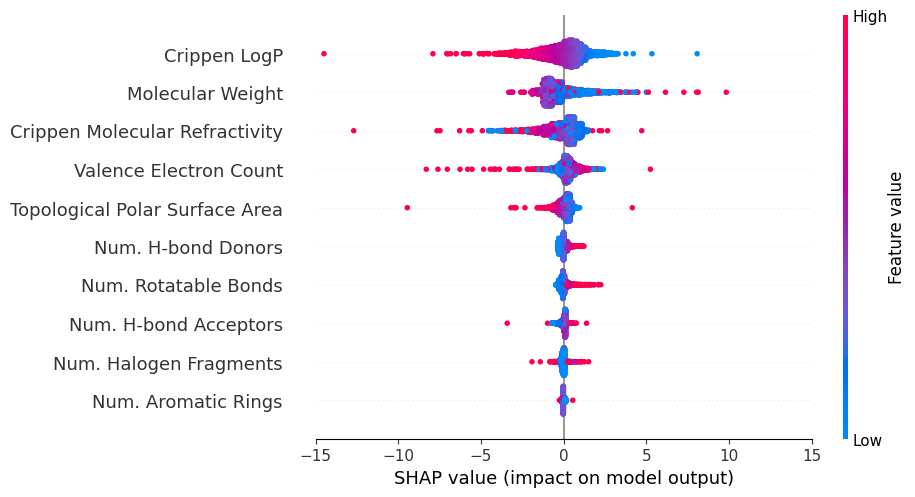

In [54]:
# --- visualizing explanations ---

ax = shap.plots.beeswarm(shap_exp, show=False, group_remaining_features=False)
ax.set_xlim(-15, 15)

**📊 Beeswarm Plot.** Contrary to the previous feature importance bar plot, the Beeswarm Plot contains additional information to indicate *how* a given feature contributes to the prediction result but is also slightly harder to read. The vertical axis again lists the human-readable name of the various features/descriptors defined above. The horizontal axis indicates the SHAP values which can be interpreted as the strength of the contribution toward the prediction outcome. These SHAP values can be positive and negative — positive values indicating that the feature pushes the prediction toward a higher value (e.g., a higher predicted probability or score), while negative values suggest the feature pulls the prediction downward.

Each point in the plot corresponds to a single instance in the dataset and is color-coded based on the feature value - typically spanning from low values (blue) to high values (high). Relative to the range of possible values observed within the dataset, a red color represents a particularly high value while a blue color represents a relatively low value. This way, one can simultaneously observe both the direction and magnitude of the effect of a feature on the model’s prediction, as well as how this varies across different samples.

The row representing Crippen's LogP descriptor should provide a particularly illustrative example of this: The left part of the plot (negative SHAP values) primarily consists of red dots, indicating high feature values, while the right part of the plot (positive SHAP values) primarily consists of blue dots, indicating low feature values. Summarizing these findings, according to these explanations, low values of Clogp are indicative towards *increased* water solubility while high values of ClogP indicate *decreased* water solubility. These findings reflect the well-known anti correlation between the octanol water partition coefficient and the water solubility logS.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.3** $\cdot$ Instead of a two-layer fully connected network, change the model to be a *four*-layer fully connected network with hidden dimensions of your own choosing and re-train the model. What changes do you observe in the explanations?

</div>

## **1.3** $\cdot$ 📚 *Locallly Interpretable Model Explanations* (`LIME`)